In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


In [20]:
# Load data (replace the path with your dataset path)
data = pd.read_csv('exported_metrics.csv')

# Convert timestamp to datetime (if necessary)
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Ensure the data is sorted by timestamp
data.sort_values('timestamp', inplace=True)

# Select relevant columns
data = data[['timestamp', 'health_status', 'uptime_seconds', 'cpu_temperature', 'process_count', 'thread_count']]

# Handle missing values (optional: you can drop or fill)
data.fillna(method='ffill', inplace=True)  # Forward fill missing values

# Label encode the health status (Healthy = 1, Unhealthy = 0)
le = LabelEncoder()
data['health_status'] = le.fit_transform(data['health_status'])

# Separate features (X) and target (y)
X = data[['uptime_seconds', 'cpu_temperature', 'process_count', 'thread_count']]  # Features
y = data['health_status']  # Target variable (health status)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


<ipython-input-20-a76a428be60d>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)  # Forward fill missing values


In [22]:
from sklearn.ensemble import RandomForestClassifier


In [23]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)


Accuracy: 32.04%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.32      0.33       397
           1       0.31      0.56      0.40       381
           2       0.32      0.11      0.17       433

    accuracy                           0.32      1211
   macro avg       0.32      0.33      0.30      1211
weighted avg       0.32      0.32      0.29      1211


Confusion Matrix:
[[127 214  56]
 [119 212  50]
 [131 253  49]]


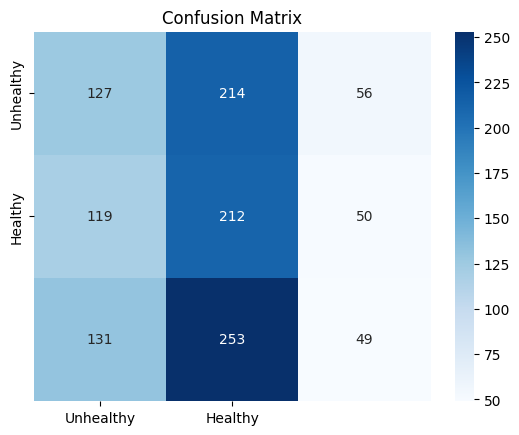

In [25]:
# Evaluate the model with accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.title('Confusion Matrix')
plt.show()


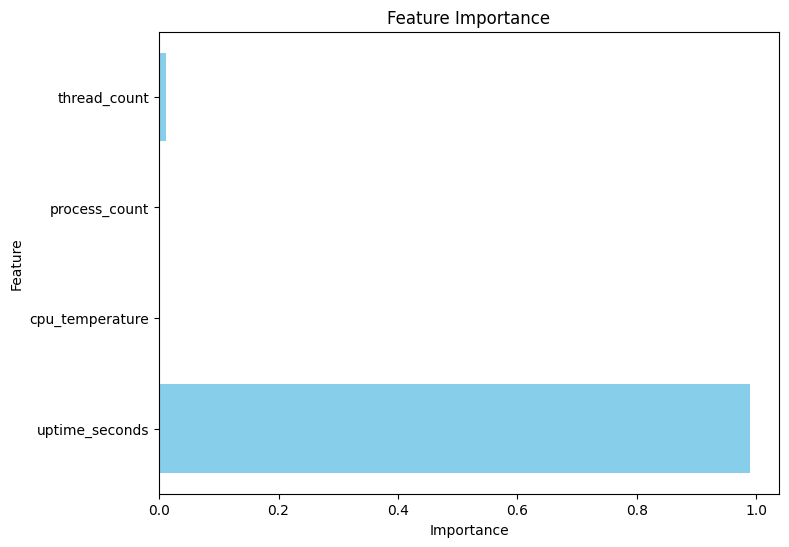

In [26]:
# Feature importance
feature_importance = rf_model.feature_importances_

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(X.columns, feature_importance, color='skyblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
